# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 04: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_04_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5859H</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/9/auto+mpg</font>

O dataset pertence ao dominio automotivo e é aplicado em problemas de regressão em apremdizado dee máquina, tendo como objetivo prever o consumo de combustível de veículos em milhas por galão (MPG) a partir de características técnicasdos automóveis. A base contem 398 instâncias de carros fabricados, com atributos multivariados como numero de cilindros, deslocamento do motor, potência do motor, peso, aceleração, ano do modelo, origem e ID do veículo, combinando variáveis contínuas e categóricas.

## <font color='green'>Preparação</font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# Importar o dataset Auto MPG (ID 9)
auto_mpg = fetch_ucirepo(id=9)

# Extrair as variáveis independentes (X) e a variável alvo (y)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# Ver as primeiras linhas
display(X.head())

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [3]:
import pandas as pd

missing_values = X.isnull().sum()
print(missing_values)

data = pd.concat([X, y], axis=1)
data_clean = data.dropna()

removed = len(data) - len(data_clean)
print(f"Quantidade de amostras removidas: {removed}")

displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64
Quantidade de amostras removidas: 6


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

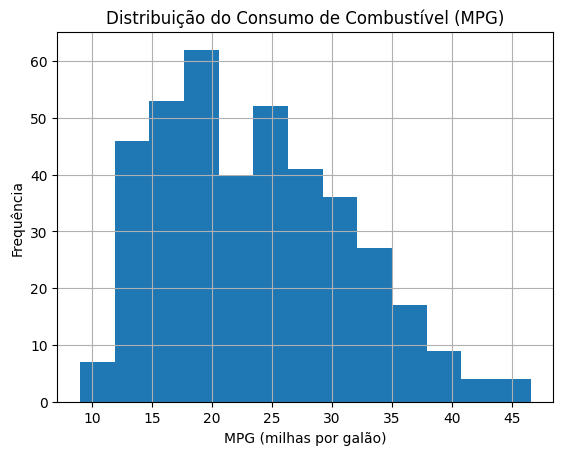

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(y, bins='fd')
plt.title("Distribuição do Consumo de Combustível (MPG)")
plt.xlabel("MPG (milhas por galão)")
plt.ylabel("Frequência")
plt.grid(True)

plt.show()

### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

A distribuição MPG mostra que a maior parte dos carros está concentrada em valores intermediários de consumo, aproximadamente entre 12 e 30 MPG, com um pico em aproximadamente 20 MPG. Isso indica que a maioria dos veículos do dataset possui eficiência moderada, enquanto há menos carros com consumo muito baixo ou muito alto.

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

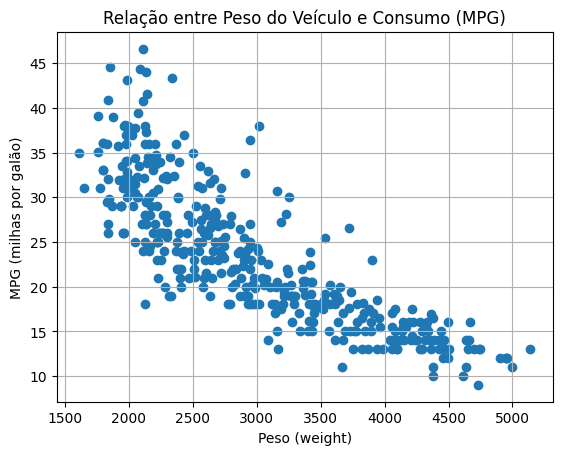

In [5]:
plt.figure()
plt.scatter(X['weight'], y)

plt.title("Relação entre Peso do Veículo e Consumo (MPG)")
plt.xlabel("Peso (weight)")
plt.ylabel("MPG (milhas por galão)")
plt.grid(True)

plt.show()

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

Apreseenta-se um relação negativa entre peso e consumo de combustível, à medida que o peso aumenta, o MPG tende a diminuir, indicando que veículos mais pesados são menos eficiêntes. Essa relação segue uma tendência aproximadamente linear decrescente, mas não é estritamente linear, pois há uma leve curvatura e dispesrsão dos pontos, principalmente para valores menores de peso.

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

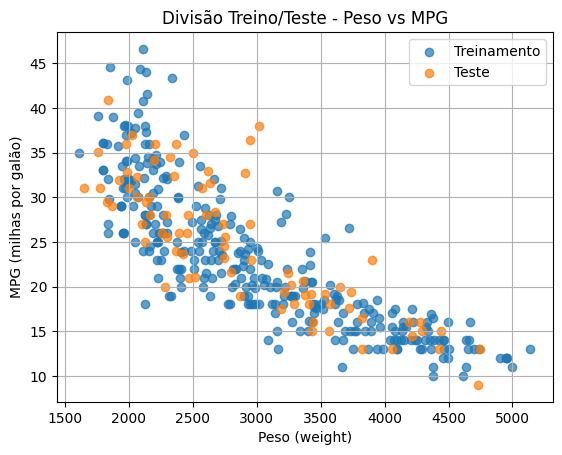

In [6]:
from sklearn.model_selection import train_test_split

X_weight = X[['weight']]

X_train, X_test, y_train, y_test = train_test_split(
    X_weight, y, test_size=0.2, random_state=1954
)

plt.figure()
plt.scatter(X_train, y_train, label='Treinamento', alpha=0.7)
plt.scatter(X_test, y_test, label='Teste', alpha=0.7)

plt.title("Divisão Treino/Teste - Peso vs MPG")
plt.xlabel("Peso (weight)")
plt.ylabel("MPG (milhas por galão)")
plt.legend()
plt.grid(True)

plt.show()

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

Sim, os pontos de ambas as cores estão bem distribuidos ao longo de toda a faixa de valores, além disso, a tendência negativa entre peso e consumo de combustível é preservada em ambos os subconjuntos, sem concentração excessiva de uma cor em regiôes específicas do gráfico.

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model = LinearRegression()

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print("=== Treinamento ===")
print(f"R²: {r2_train:.4f}")
print(f"MAE: {mae_train:.4f}")
print(f"MSE: {mse_train:.4f}")

print("\n=== Teste ===")
print(f"R²: {r2_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"MSE: {mse_test:.4f}")

=== Treinamento ===
R²: 0.6962
MAE: 3.2961
MSE: 18.8034

=== Teste ===
R²: 0.6590
MAE: 3.2346
MSE: 18.7776


### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

Os erros de trinamento e teste e R² são muito semelhantes, o que indica que o modelo generaliza bem para novos dados. Como não há grande diferença entre treino e teste, não há sinaisde overfitting, e como o modelo ainda explica uma boa parte da variação dos dados, também não há underfitting, portanto ele apresenta um bom ajuste,com equilibrio entre viés e variância.

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

model_poly.fit(X_train, y_train)

y_train_pred_poly = model_poly.predict(X_train)
y_test_pred_poly = model_poly.predict(X_test)

r2_train_poly = r2_score(y_train, y_train_pred_poly)
mae_train_poly = mean_absolute_error(y_train, y_train_pred_poly)
mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)

r2_test_poly = r2_score(y_test, y_test_pred_poly)
mae_test_poly = mean_absolute_error(y_test, y_test_pred_poly)
mse_test_poly = mean_squared_error(y_test, y_test_pred_poly)

print("=== Treinamento ===")
print(f"R²: {r2_train_poly:.4f}")
print(f"MAE: {mae_train_poly:.4f}")
print(f"MSE: {mse_train_poly:.4f}")

print("\n=== Teste ===")
print(f"R²: {r2_test_poly:.4f}")
print(f"MAE: {mae_test_poly:.4f}")
print(f"MSE: {mse_test_poly:.4f}")

=== Treinamento ===
R²: 0.7299
MAE: 3.0009
MSE: 16.7161

=== Teste ===
R²: 0.6289
MAE: 3.3198
MSE: 20.4347


### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

O modelo polinomial apresenta melhor desempenho no trinamento, porém piora no conjunto de teste, indicando que ele se ajustou melhor aos dados de treino, mas perdeu a capacidade de generalização. Essa diferença entre treino e teste caracteriza um leve overfitting, pois o modelo está capturando padrões específicos do treino que não se repetem tão bem nos dados novos.

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

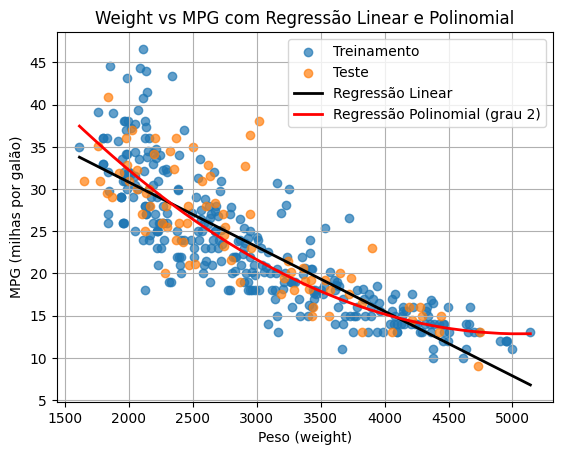

In [9]:
plt.figure()

plt.scatter(X_train['weight'], y_train.values.ravel(), label='Treinamento', alpha=0.7)
plt.scatter(X_test['weight'], y_test.values.ravel(), label='Teste', alpha=0.7)

x_plot = X_weight.sort_values('weight')

plt.plot(
    x_plot['weight'],
    model.predict(x_plot),
    label='Regressão Linear',
    linewidth=2,
    color='black'
)

plt.plot(
    x_plot['weight'],
    model_poly.predict(x_plot),
    label='Regressão Polinomial (grau 2)',
    linewidth=2,
    color='red'
)

plt.title('Weight vs MPG com Regressão Linear e Polinomial')
plt.xlabel('Peso (weight)')
plt.ylabel('MPG (milhas por galão)')
plt.legend()
plt.grid(True)

plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

Com base no gráfico, o modelo de regressão polinomial parece se ajustar melhor aos dados, pois sua curva acompanha a distribuição dos ontos, especialmente nas regiões de pesos menores e maiores, onde há uma leve curvatura. A relação entre weight e mpg parece ser nãolinear, apesentando uma tendência decrescente com curvatura, o que explica por que o modelo polinomial consegue capturar melhor esse comportamento.

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

São parcialmente consistentes. Visualmente a regressão polinomial parece acompanharmelhor a curvatura dos dados, mas as métricas mostram que ela melhora apenas no trenamento e piora no teste, indicando um leve overfiting. Já a regrssão linear parece mais simples visualmente, porém apresentou melhor generalização no conjunto de teste. Isso ostra que a avaliação visual ajuda a entender o formato da relação entre as variáveis, mas as métricas são mais confiáveis para avaliar desempenho preditivo.

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [10]:
model_poly_high = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

model_poly_high.fit(X_train, y_train)

y_train_pred_poly_high = model_poly_high.predict(X_train)
y_test_pred_poly_high = model_poly_high.predict(X_test)

r2_train_poly_high = r2_score(y_train, y_train_pred_poly_high)
mae_train_poly_high = mean_absolute_error(y_train, y_train_pred_poly_high)
mse_train_poly_high = mean_squared_error(y_train, y_train_pred_poly_high)

r2_test_poly_high = r2_score(y_test, y_test_pred_poly_high)
mae_test_poly_high = mean_absolute_error(y_test, y_test_pred_poly_high)
mse_test_poly_high = mean_squared_error(y_test, y_test_pred_poly_high)

print("=== Treinamento ===")
print(f"R²: {r2_train_poly_high:.4f}")
print(f"MAE: {mae_train_poly_high:.4f}")
print(f"MSE: {mse_train_poly_high:.4f}")

print("\n=== Teste ===")
print(f"R²: {r2_test_poly_high:.4f}")
print(f"MAE: {mae_test_poly_high:.4f}")
print(f"MSE: {mse_test_poly_high:.4f}")

=== Treinamento ===
R²: 0.7422
MAE: 2.9314
MSE: 15.9533

=== Teste ===
R²: 0.5690
MAE: 3.4893
MSE: 23.7288


O desempenho do conjunto de teste piora em relação ao treinamento. O modelo apresenta R² maior e erros menores no treino, mas no teste o R² cai e os erros aumentam. Isso indica overfitting, pois o polinômio de grau alto de adapta demais aos padrões e ruídos específicos do conjunto de treinamento, mas perde a capacidade de generalizar.

## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [11]:
from sklearn.linear_model import SGDRegressor

sgd_model = SGDRegressor(random_state=1954)

sgd_model.fit(X_train, y_train.values.ravel())

y_train_pred_sgd = sgd_model.predict(X_train)
y_test_pred_sgd = sgd_model.predict(X_test)

print("=== Treinamento - SGD sem escalonamento ===")
print(f"R²: {r2_score(y_train, y_train_pred_sgd):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_sgd):.4f}")
print(f"MSE: {mean_squared_error(y_train, y_train_pred_sgd):.4f}")

print("\n=== Teste - SGD sem escalonamento ===")
print(f"R²: {r2_score(y_test, y_test_pred_sgd):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_sgd):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred_sgd):.4f}")

=== Treinamento - SGD sem escalonamento ===
R²: -19598685398761353123358310400.0000
MAE: 1058743481109389.6250
MSE: 1212850137402000577948236644352.0000

=== Teste - SGD sem escalonamento ===
R²: -20063638762182843158073704448.0000
MAE: 1013500317249233.3750
MSE: 1104680751663468285735613759488.0000


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sgd_model_scaled = SGDRegressor(random_state=1954)

sgd_model_scaled.fit(X_train_scaled, y_train.values.ravel())

y_train_pred_sgd_scaled = sgd_model_scaled.predict(X_train_scaled)
y_test_pred_sgd_scaled = sgd_model_scaled.predict(X_test_scaled)

print("=== Treinamento - SGD com escalonamento ===")
print(f"R²: {r2_score(y_train, y_train_pred_sgd_scaled):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_sgd_scaled):.4f}")
print(f"MSE: {mean_squared_error(y_train, y_train_pred_sgd_scaled):.4f}")

print("\n=== Teste - SGD com escalonamento ===")
print(f"R²: {r2_score(y_test, y_test_pred_sgd_scaled):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_sgd_scaled):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred_sgd_scaled):.4f}")

=== Treinamento - SGD com escalonamento ===
R²: 0.6961
MAE: 3.2978
MSE: 18.8036

=== Teste - SGD com escalonamento ===
R²: 0.6591
MAE: 3.2353
MSE: 18.7689


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

Os resultados mostram um diferença drástica. Sem escalonamento, o SGD apresenta erros extremamentes altos e R² negativo, indicando que o modelo não convergiu. Já com escalonamento, os resultados ficam estáveis e praticamente iguais à regressão linear. Isso ocorre porque algoritmos baseados em gradiente descendente são sensíveis à escala das variáveis. Ao aplicar normalização, os dados passam a ter média 0 e variância unitária, o que equilibra a superfície de erro, permite atualizações mais consistentes dogradiente e garante uma convergência eficiênte para o mínimo da função custo.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [13]:
from sklearn.linear_model import Lasso

valid_idx = X.notnull().all(axis=1) & y.notnull().all(axis=1)

X_all = X.loc[valid_idx]
y_all = y.loc[valid_idx].values.ravel()

lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0, random_state=1954))
])

lasso_model.fit(X_all, y_all)

coeficientes = pd.Series(
    lasso_model.named_steps['lasso'].coef_,
    index=X_all.columns
)

print("Coeficientes finais do LASSO:")
print(coeficientes)

Coeficientes finais do LASSO:
displacement   -0.000000
cylinders      -0.000000
horsepower     -0.167700
weight         -4.545532
acceleration    0.000000
model_year      1.994436
origin          0.308290
dtype: float64


Sim, a normalização mudou a forma como o modelo avalia a importância das variáveis, porque agora os coeficiêntes passam a ser comparados em uma base justa. Sem normalização, variáveis em escalas maiores podem dominar o processo de ajuste apenas por causa da magnitude numérica, e no caso da Q16 isso foi tão grave que SGDRegrssor nem convergiu. Já com o StandartScaler, todas as variáveis ficam na mesma escala, então o LASSO penaliza os coeficiêntes de forma equilibrada e consegue selecionar melhor o que realmente contribui para a predição, zerando variáveis menos úteis.

### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

In [14]:
alphas = [0.1, 1.0, 5.0]

for alpha in alphas:
    lasso_model = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, random_state=1954))
    ])

    lasso_model.fit(X_all, y_all)

    coeficientes = pd.Series(
        lasso_model.named_steps['lasso'].coef_,
        index=X_all.columns
    )

    sobreviventes = coeficientes[coeficientes != 0].index.tolist()

    print(f"alpha = {alpha}")
    print(sobreviventes)
    print()

alpha = 0.1
['horsepower', 'weight', 'acceleration', 'model_year', 'origin']

alpha = 1.0
['horsepower', 'weight', 'model_year', 'origin']

alpha = 5.0
['weight']



À medida que o valor de alpha aumenta, a regularização fica mais forte e o modelo se torna mais simples, porque mais coeficiêntes são reduzidos a zero. Ou seja, aumentar o alpha reduz a complexidade do modelo, diminui o risco de overfitting, mas, se o valor ficar alto demais, o modelo pode simplificar em excesso e perder informação relevante, levando a underfiting.